In [8]:
import numpy as np
def load_relic(index):
    idx = index if index >=10 else ('0' + str(index))
    path = f'dataset/relic_{idx}'
    shadows = np.load(f'{path}/intensities.npy')
    rotations = np.load(f'{path}/rotations.npy')
    return shadows, rotations

relic_shadows, relic_rotations = load_relic(0)

<Axes: >

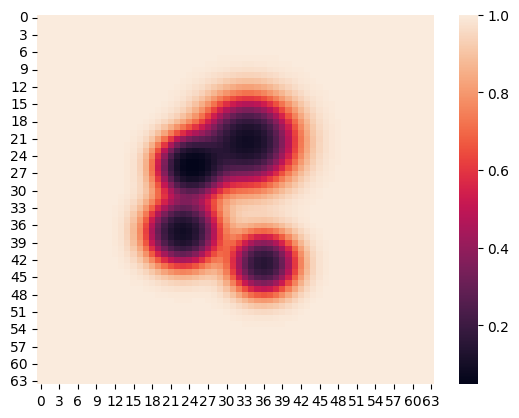

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
shadow, R = relic_shadows[0], relic_rotations[0]
sns.heatmap(shadow)

In [122]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [162]:
device = 'cuda'

def get_shadow(V, R):
    B = R.shape[0]

    lin = torch.linspace(-1, 1, 64, device=device)
    x, y, z = torch.meshgrid(lin, lin, lin, indexing='ij')

    grid = torch.stack([x, y, z], dim=-1).view(-1, 3)

    grid = grid.unsqueeze(0).expand(B, -1, -1)
    grid = torch.bmm(grid, R.transpose(1, 2))
    grid = grid.view(B, 64, 64, 64, 3)

    Vb = V.expand(B, -1, -1, -1, -1)
    Vg = F.grid_sample(
        Vb,
        grid,
        mode='bilinear',
        align_corners=True
    )
    pred = torch.exp(-Vg.sum(dim=2))
    return pred

In [177]:
relic_labels, relic_rotations = load_relic(0)

relic_labels = torch.tensor(relic_labels, device=device)
relic_rotations = torch.tensor(relic_rotations, device=device)

ds = TensorDataset(relic_labels, relic_rotations)
loader = DataLoader(ds, batch_size=4)

EPOCHS = 10000

V = torch.nn.Parameter(
    0.001 * torch.rand((1, 1, 64, 64, 64), device=device),
    requires_grad=True
)

criterion = nn.MSELoss()
optim = torch.optim.Adam([V], lr=1e-5)

for epoch in range(EPOCHS):
    for label, R in loader:

        label = label.to(device)
        R = R.to(device)

        optim.zero_grad()

        pred = get_shadow(V, R)

        tv = (
            (V[:,:,1:,:,:]-V[:,:,:-1,:,:]).abs().mean() +
            (V[:,:,:,1:,:]-V[:,:,:,:-1,:]).abs().mean() +
            (V[:,:,:,:,1:]-V[:,:,:,:,:-1]).abs().mean()
        )

        loss = criterion(pred, label) + 1e-4 * tv

        loss.backward()
        optim.step()

        with torch.no_grad():
            V.clamp_(0, 1)

    if epoch % 1000 == 0:
        print(loss.item())

0.05448747053742409
0.020691359415650368
0.020696071907877922
0.020691869780421257
0.02068810537457466


KeyboardInterrupt: 

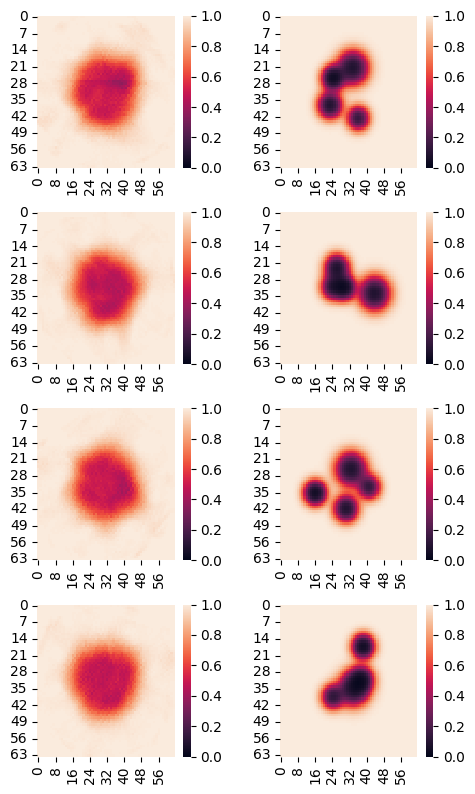

In [175]:
labels, Rs = next(iter(loader))
labels = labels.cpu().numpy()
preds = get_shadow(V, R).cpu().detach().numpy()
fig, ax = plt.subplots(nrows=4, ncols=2)
fig.set_size_inches(5, 8)
plt.tight_layout()
for i, (pred, label) in enumerate(zip(preds, labels)):
    sns.heatmap(pred[0], ax=ax[i,0], vmin=0, vmax=1)
    sns.heatmap(label, ax=ax[i,1], vmin=0, vmax=1)

In [32]:
# from scipy.ndimage import affine_transform
# from scipy.optimize import minimize

# V = np.random.rand(64,64,64)
# c = np.array([31.5, 31.5, 31.5])

# def loss(v):
#     v = v.reshape(64,64,64)
#     R_inv = np.linalg.inv(R)
#     offset = c - R_inv @ c
#     V_prim = affine_transform(v, R_inv, offset=offset)
#     I_pred = np.exp(-np.sum(V_prim, axis=2))
#     return np.sum((I_pred-shadow)**2)
# res = minimize(loss, V.ravel())

KeyboardInterrupt: 